<a href="https://colab.research.google.com/github/shllangermann/dsrp-repo/blob/main/DSRP_2026_langermann.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DSRP 2026
Research Question: TBD

Possible Questions:

- What is the relationship between an author's presence in the bestsellers list and the rank that their books get?


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [83]:
bestsell_df = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2022/2022-05-10/nyt_titles.tsv', sep='\t')
bestsell_df.head()

,id,title,author,year,total_weeks,first_week,debut_rank,best_rank
0,0,"""H"" IS FOR HOMICIDE",Sue Grafton,1991,15,1991-05-05,1,2
1,1,"""I"" IS FOR INNOCENT",Sue Grafton,1992,11,1992-04-26,14,2
2,10,''G'' IS FOR GUMSHOE,Sue Grafton,1990,6,1990-05-06,4,8
3,100,A DOG'S JOURNEY,W. Bruce Cameron,2012,1,2012-05-27,3,14
4,1000,CHANGING FACES,Kimberla Lawson Roby,2006,1,2006-02-19,11,14


In [89]:
bestsell_df.info()
# 4 missing values in "author"
# PROBLEM: authors are in the wrong column
bestsell_df[bestsell_df['author'].isnull()]
bestsell_df = bestsell_df.drop_duplicates()
bestsell_df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7431 entries, 0 to 7430
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           7431 non-null   int64 
 1   title        7431 non-null   object
 2   author       7427 non-null   object
 3   year         7431 non-null   int64 
 4   total_weeks  7431 non-null   int64 
 5   first_week   7431 non-null   object
 6   debut_rank   7431 non-null   int64 
 7   best_rank    7431 non-null   int64 
dtypes: int64(5), object(3)
memory usage: 464.6+ KB


,id,title,author,year,total_weeks,first_week,debut_rank,best_rank
0,0,"""H"" IS FOR HOMICIDE",Sue Grafton,1991,15,1991-05-05,1,2
1,1,"""I"" IS FOR INNOCENT",Sue Grafton,1992,11,1992-04-26,14,2
2,10,''G'' IS FOR GUMSHOE,Sue Grafton,1990,6,1990-05-06,4,8
3,100,A DOG'S JOURNEY,W. Bruce Cameron,2012,1,2012-05-27,3,14
4,1000,CHANGING FACES,Kimberla Lawson Roby,2006,1,2006-02-19,11,14
...,...,...,...,...,...,...,...,...
7426,995,CHANCES,Jackie Collins,1981,1,1981-10-04,1,15
7427,996,CHANCES ARE ...,Richard Russo,2019,3,2019-08-18,5,8
7428,997,CHANGE OF HEART,Jodi Picoult,2008,8,2008-03-23,9,1
7429,998,CHANGES,Danielle Steel,1983,28,1983-09-11,12,2


In [92]:
bestsell_df['title'] = bestsell_df['title'].replace({'EAST AND WEST, by Somerset Maugham. (Doubleday, Doran.)':'EAST AND WEST', 'HOLY DEADLOCK, by A. P. Herbert. (Doubleday, Doran.)':'HOLY DEADLOCK', 'MUTINY ON THE BOUNTY, Charles Nordhoff and James N. Hall. (Little, Brown.)':'MUTINY ON THE BOUNTY', 'A CITY OF BELLS, by Elizabeth Goudge. (Coward-McCann.)':'A CITY OF BELLS'})
bestsell_df

,id,title,author,year,total_weeks,first_week,debut_rank,best_rank
0,0,"""H"" IS FOR HOMICIDE",Sue Grafton,1991,15,1991-05-05,1,2
1,1,"""I"" IS FOR INNOCENT",Sue Grafton,1992,11,1992-04-26,14,2
2,10,''G'' IS FOR GUMSHOE,Sue Grafton,1990,6,1990-05-06,4,8
3,100,A DOG'S JOURNEY,W. Bruce Cameron,2012,1,2012-05-27,3,14
4,1000,CHANGING FACES,Kimberla Lawson Roby,2006,1,2006-02-19,11,14
...,...,...,...,...,...,...,...,...
7426,995,CHANCES,Jackie Collins,1981,1,1981-10-04,1,15
7427,996,CHANCES ARE ...,Richard Russo,2019,3,2019-08-18,5,8
7428,997,CHANGE OF HEART,Jodi Picoult,2008,8,2008-03-23,9,1
7429,998,CHANGES,Danielle Steel,1983,28,1983-09-11,12,2


In [82]:
print('Range:', (bestsell_df['year'].max() - bestsell_df['year'].min()))
bestsell_df.describe()

Range: 89


,id,year,total_weeks,debut_rank,best_rank
count,7431.000000,7431.000000,7431.000000,7431.000000,7431.000000
mean,3715.000000,1989.605168,8.126228,7.897726,6.914278
std,2145.289258,26.234540,11.208171,4.574437,4.567460
min,0.000000,1931.000000,1.000000,1.000000,1.000000
25%,1857.500000,1968.000000,2.000000,4.000000,3.000000
50%,3715.000000,2000.000000,4.000000,8.000000,6.000000
75%,5572.500000,2011.000000,10.000000,12.000000,10.000000
max,7430.000000,2020.000000,178.000000,17.000000,17.000000


In [94]:
# top 5 list
top_authors = bestsell_df['author'].value_counts().nlargest(5).index
top_authors

Index(['Danielle Steel', 'Stuart Woods', 'Stephen King', 'Robert B. Parker',
       'John Sandford'],
      dtype='object', name='author')

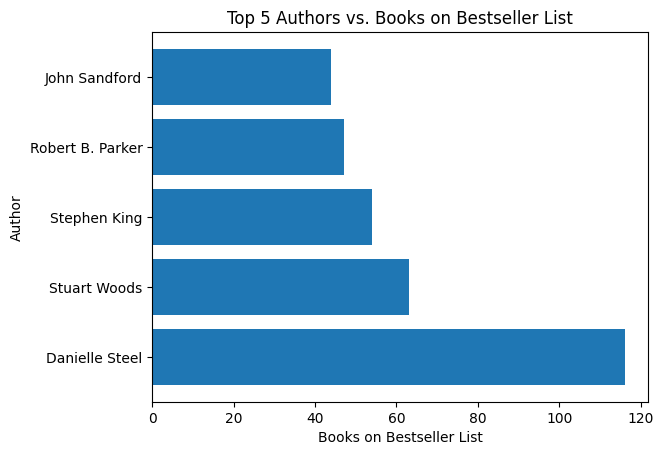

In [98]:
# bar plot
# danielle steel has the most books on the bestseller list
filtered_data = bestsell_df[bestsell_df['author'].isin(top_authors)]
bars = filtered_data['author'].value_counts()

plt.barh(bars.index, bars)

plt.ylabel('Author')
plt.xlabel('Books on Bestseller List')
plt.title('Top 5 Authors vs. Books on Bestseller List')

plt.show()
